python mesa ile 100 ajandan oluşan bir model oluşturup ajanları AgentSet() içine alan Kod


Bu kodda:

MyAgent adında basit bir ajan sınıfı oluşturduk.

MyModel içinde 100 ajan oluşturduk ve bunları rastgele hücrelere yerleştirdik.

schedule.agents ile tüm ajanlara erişebilirsiniz (bu bir AgentSet'tir).

Modeli 10 adım çalıştırdık.

Gruplama, Sıralama yaptık


In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.4 MB/s eta 0:00:00


In [32]:

from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import random

# Ajan sınıfını tanımlayalım
class MyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.active = random.choice([True, False])
        self.wealth = random.randint(0, 100)
        self.group = "A" if self.unique_id % 2 == 0 else "B"  # Çift-ID'liler "A" grubu
        self.alis_fiyati = 0
        self.alis_miktari = 0



    def say_hi(self):
        print(
            f"Merhaba! Ben {self.unique_id}, "
            f"Servetim: {self.wealth}, "
            f"Aktif mi? {self.active}, "
            f"Grubum: {self.group}"
        )


    def step(self):
        # Ajanın her adımda yapacağı işlemler
        print(f"Ajan ID: {self.unique_id}- Servet: {self.wealth}")
        self.say_hi()

        self.alis_fiyati = random.randint(10, 100)

        self.alis_miktari = random.randint(1, 10)

        self.model.rich_agents.append(self)


# Model sınıfını tanımlayalım
class MyModel(mesa.Model):
    def __init__(self, N, width, height):
        super().__init__()
        self.num_agents = N
        self.grid = MultiGrid(width, height, True)

        self.rich_agents = []


        # Ajanları oluşturalım
        for i in range(self.num_agents):
            agent = MyAgent(self)
            self.agents.add(agent)

            # Ajanları rastgele bir hücreye yerleştirelim
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(agent, (x, y))

        # Veri toplamak için DataCollector kullanabiliriz (opsiyonel)
        self.datacollector = DataCollector()



    # Modelde filtreleme:
    def get_group_a(self):
        return self.agents.select(lambda agent: agent.group == "A")


    # Dinamik Ajan Ekleyip Çıkarma

    def dynamic_agents(self):
        # diğer piyasalara ilişkin kötü haberler arttığında ve mevcut piyasaya ilşkin iyi haberler arttığında, piyasaya ajan girişi diğer zamanlardaki
        # girişlerden daha çok olacaktır. Bu nedenle piyasaya gelen haberlere göre ajan girişi olacak
        if random.random() > 0.5: #iyi haber geldi, 100 yeni ajan girdi
            # Yeni ajan ekle
            for i in range(int(0.25 * len(self.agents))):   # yeni giriş yapan ajanların sayısını, mevcut ajan sayısının belli bir oranı olarak ayarlanabilir.
                new_agent = MyAgent(self)
                self.agents.add(new_agent)
            print(f"Yeni eklenen ajan SAYISI: {(int(0.25 * len(self.agents)))}")
        else:                    # iyi haber yok, 10 yeni ajan girdi
            # Yeni ajan ekle
            for i in range(int(0.10 * len(self.agents))):
                new_agent = MyAgent(self)
                self.agents.add(new_agent)
            print(f"Yeni eklenen ajan sayısİ: {(int(0.10 * len(self.agents)))}")

        print(f"Güncel Ajan SAyısı: {len(self.agents)}")

        """
        # 5 ID'li ajanı sil
        agent_to_remove = next(a for a in self.agents if a.unique_id == 5)
        self.agents.remove(agent_to_remove)
        """




    def step(self):
        # Modelin her adımda yapacağı işlemler
        self.agents.do("step")
        self.dynamic_agents()

        self.datacollector.collect(self)

# Modeli oluşturalım (100 ajan, 10x10 grid)
model = MyModel(10, 10, 10)

# Tüm ajanları AgentSet olarak almak için:
all_agents = model.agents

# AgentSet'i kontrol edelim
print(f"Toplam ajan sayısı: {len(all_agents)}")
print(f"İlk ajanın ID'si: {all_agents[0].unique_id}")

# Modeli birkaç adım çalıştıralım
for i in range(10):
    print(f"------Adım {i+1}--------")
    model.step()

Toplam ajan sayısı: 10
İlk ajanın ID'si: 1
------Adım 1--------
Ajan ID: 1- Servet: 2
Merhaba! Ben 1, Servetim: 2, Aktif mi? False, Grubum: B
Ajan ID: 2- Servet: 39
Merhaba! Ben 2, Servetim: 39, Aktif mi? False, Grubum: A
Ajan ID: 3- Servet: 76
Merhaba! Ben 3, Servetim: 76, Aktif mi? True, Grubum: B
Ajan ID: 4- Servet: 30
Merhaba! Ben 4, Servetim: 30, Aktif mi? True, Grubum: A
Ajan ID: 5- Servet: 40
Merhaba! Ben 5, Servetim: 40, Aktif mi? True, Grubum: B
Ajan ID: 6- Servet: 24
Merhaba! Ben 6, Servetim: 24, Aktif mi? True, Grubum: A
Ajan ID: 7- Servet: 79
Merhaba! Ben 7, Servetim: 79, Aktif mi? True, Grubum: B
Ajan ID: 8- Servet: 6
Merhaba! Ben 8, Servetim: 6, Aktif mi? False, Grubum: A
Ajan ID: 9- Servet: 80
Merhaba! Ben 9, Servetim: 80, Aktif mi? False, Grubum: B
Ajan ID: 10- Servet: 7
Merhaba! Ben 10, Servetim: 7, Aktif mi? False, Grubum: A
Yeni eklenen ajan SAYISI: 3
Güncel Ajan SAyısı: 12
------Adım 2--------
Ajan ID: 1- Servet: 2
Merhaba! Ben 1, Servetim: 2, Aktif mi? False, Grubu

In [3]:

# Mevcut ajanlardan bir AgentSet oluşturalım
#agent_set = AgentSet(model.agents)

# AgentSet üzerinde işlemler yapabiliriz
print(f"AgentSet boyutu: {all_agents[0]}")

AgentSet boyutu: <__main__.MyAgent object at 0x7fabd41fd9d0>


In [4]:
# Access agent attributes

for agent in all_agents:
       print(agent.unique_id)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45


In [5]:
# Assuming agents have an 'active' attribute

def is_active(agent):
       return agent.active

# Use a list comprehension to filter agents
active_agents = [agent for agent in all_agents if is_active(agent)]

# active_agents now contains a list of active agents

for agent in active_agents:
       print(agent.unique_id)



4
6
9
10
11
12
15
16
18
19
20
21
23
24
26
27
29
31
33
35
36
37
38
40
45


In [6]:
# Sort by agent's 'wealth' attribute
all_agents.sort(key=lambda agent: agent.wealth, ascending=False)  # Sort using a lambda function

# Accessing the first agent after sorting (or any specific agent by index)
print(f"First Agent - Unique ID: {all_agents[0].unique_id}, Active: {all_agents[0].active}, Wealth: {all_agents[0].wealth}")


First Agent - Unique ID: 1, Active: False, Wealth: 86


In [7]:
# Sort by agent's 'wealth' attribute
all_agents.sort(key=lambda agent: agent.wealth, ascending=False)  # Sort using a lambda function

# Iterate through the sorted agents and print their attributes
for agent in all_agents:
    print(f"Agent - Unique ID: {agent.unique_id}, Active: {agent.active}, Wealth: {agent.wealth}")

Agent - Unique ID: 1, Active: False, Wealth: 86
Agent - Unique ID: 2, Active: False, Wealth: 86
Agent - Unique ID: 3, Active: False, Wealth: 48
Agent - Unique ID: 4, Active: True, Wealth: 48
Agent - Unique ID: 5, Active: False, Wealth: 81
Agent - Unique ID: 6, Active: True, Wealth: 40
Agent - Unique ID: 7, Active: False, Wealth: 52
Agent - Unique ID: 8, Active: False, Wealth: 21
Agent - Unique ID: 9, Active: True, Wealth: 59
Agent - Unique ID: 10, Active: True, Wealth: 73
Agent - Unique ID: 11, Active: True, Wealth: 21
Agent - Unique ID: 12, Active: True, Wealth: 45
Agent - Unique ID: 13, Active: False, Wealth: 100
Agent - Unique ID: 14, Active: False, Wealth: 14
Agent - Unique ID: 15, Active: True, Wealth: 80
Agent - Unique ID: 16, Active: True, Wealth: 69
Agent - Unique ID: 17, Active: False, Wealth: 17
Agent - Unique ID: 18, Active: True, Wealth: 87
Agent - Unique ID: 19, Active: True, Wealth: 86
Agent - Unique ID: 20, Active: True, Wealth: 23
Agent - Unique ID: 21, Active: True, We

In [8]:
random_agent = all_agents.random.choice(all_agents)
print(f"Random Agent - Unique ID: {random_agent.unique_id}, Active: {random_agent.active}, Wealth: {random_agent.wealth}")

Random Agent - Unique ID: 19, Active: True, Wealth: 86


In [9]:
# Print the unique_id of the first agent before sorting
print(f"First agent before sorting: {all_agents[0].unique_id}")

# Sort by agent's 'wealth' attribute
all_agents.sort(key=lambda agent: agent.wealth, ascending=False)

# Print the unique_id of the first agent after sorting
print(f"First agent after sorting: {all_agents[0].unique_id}")

First agent before sorting: 1
First agent after sorting: 1


In [10]:
# Print the unique_id of the first agent before sorting
print(f"First agent before sorting: {all_agents[0].unique_id}")

# Sort by agent's 'wealth' attribute
sorted_agent_with_wealth= all_agents.sort(key=lambda agent: agent.wealth, ascending=False)

# Print the unique_id of the first agent after sorting
print(f"First agent after sorting: {sorted_agent_with_wealth[0].unique_id}")

First agent before sorting: 1
First agent after sorting: 13


In [11]:
# Create a sorted copy using the sorted() function
sorted_agents = sorted(all_agents, key=lambda agent: agent.wealth, reverse=True)

# Now, sorted_agents contains the sorted agents, and all_agents remains unchanged

for agent in sorted_agents:
    print(f"Agent - Unique ID: {agent.unique_id}, Active: {agent.active}, Wealth: {agent.wealth}")

Agent - Unique ID: 13, Active: False, Wealth: 100
Agent - Unique ID: 37, Active: True, Wealth: 97
Agent - Unique ID: 31, Active: True, Wealth: 95
Agent - Unique ID: 44, Active: False, Wealth: 95
Agent - Unique ID: 26, Active: True, Wealth: 88
Agent - Unique ID: 18, Active: True, Wealth: 87
Agent - Unique ID: 1, Active: False, Wealth: 86
Agent - Unique ID: 2, Active: False, Wealth: 86
Agent - Unique ID: 19, Active: True, Wealth: 86
Agent - Unique ID: 5, Active: False, Wealth: 81
Agent - Unique ID: 15, Active: True, Wealth: 80
Agent - Unique ID: 39, Active: False, Wealth: 80
Agent - Unique ID: 10, Active: True, Wealth: 73
Agent - Unique ID: 34, Active: False, Wealth: 72
Agent - Unique ID: 16, Active: True, Wealth: 69
Agent - Unique ID: 22, Active: False, Wealth: 69
Agent - Unique ID: 23, Active: True, Wealth: 61
Agent - Unique ID: 21, Active: True, Wealth: 60
Agent - Unique ID: 9, Active: True, Wealth: 59
Agent - Unique ID: 43, Active: False, Wealth: 59
Agent - Unique ID: 29, Active: Tru

In [12]:
# Grubu yazdırma:
group_a = model.get_group_a()
print(f"A grubundaki ajan sayısı: {len(group_a)}")

A grubundaki ajan sayısı: 22


In [13]:
# Dinamik Ajan Ekleyip Çıkarma

model.dynamic_agents()


Yeni eklenen ajan sayısİ: 4
Güncel Ajan SAyısı: 49


In [14]:
# model.agents.select - koşula uyan ajanları seçer

serveti_10dan_buyuk= model.agents.select(lambda a: a.wealth > 10)
print(f"Servet 10'dan büyük olan ajan sayısı: {len(serveti_10dan_buyuk)}")

Servet 10'dan büyük olan ajan sayısı: 44


In [15]:
# ajanları alt gruplara ayır

# Calculate the number of agents for each group
num_agents_group1 = int(len(model.agents) * 0.3)
num_agents_group2 = len(model.agents) - num_agents_group1

# Create the groups using slicing
group1 = model.agents[:num_agents_group1]
group2 = model.agents[num_agents_group1:]

print("Group1:")
for agent in group1:
    print(f"  Agent - Unique ID: {agent.unique_id}, Active: {agent.active}, Wealth: {agent.wealth}")

print("\nGroup2:")
for agent in group2:
    print(f"  Agent - Unique ID: {agent.unique_id}, Active: {agent.active}, Wealth: {agent.wealth}")


# Now, group1 and group2 contain the desired subgroups of agents

Group1:
  Agent - Unique ID: 1, Active: False, Wealth: 86
  Agent - Unique ID: 2, Active: False, Wealth: 86
  Agent - Unique ID: 3, Active: False, Wealth: 48
  Agent - Unique ID: 4, Active: True, Wealth: 48
  Agent - Unique ID: 5, Active: False, Wealth: 81
  Agent - Unique ID: 6, Active: True, Wealth: 40
  Agent - Unique ID: 7, Active: False, Wealth: 52
  Agent - Unique ID: 8, Active: False, Wealth: 21
  Agent - Unique ID: 9, Active: True, Wealth: 59
  Agent - Unique ID: 10, Active: True, Wealth: 73
  Agent - Unique ID: 11, Active: True, Wealth: 21
  Agent - Unique ID: 12, Active: True, Wealth: 45
  Agent - Unique ID: 13, Active: False, Wealth: 100
  Agent - Unique ID: 14, Active: False, Wealth: 14

Group2:
  Agent - Unique ID: 15, Active: True, Wealth: 80
  Agent - Unique ID: 16, Active: True, Wealth: 69
  Agent - Unique ID: 17, Active: False, Wealth: 17
  Agent - Unique ID: 18, Active: True, Wealth: 87
  Agent - Unique ID: 19, Active: True, Wealth: 86
  Agent - Unique ID: 20, Active:

In [16]:
# İlk 5 ajanın özelliklerini yazdır
for agent in list(model.agents)[:5]:
    print(
        f"Ajan {agent.unique_id}: "
        f"Servet={agent.wealth}, "
        f"Aktif mi?={agent.active}, "

    )

Ajan 1: Servet=86, Aktif mi?=False, 
Ajan 2: Servet=86, Aktif mi?=False, 
Ajan 3: Servet=48, Aktif mi?=False, 
Ajan 4: Servet=48, Aktif mi?=True, 
Ajan 5: Servet=81, Aktif mi?=False, 


In [17]:
# Tüm ajanların özelliklerine erişip değer atama/ değişiklik yapma
# Tüm ajanların servetini artırma
for agent in model.agents:
    agent.wealth += 10

for agent in list(model.agents)[:5]:
    print(
        f"Ajan {agent.unique_id}: "
        f"Servet={agent.wealth}, "
        f"Aktif mi?={agent.active}, "

    )

Ajan 1: Servet=96, Aktif mi?=False, 
Ajan 2: Servet=96, Aktif mi?=False, 
Ajan 3: Servet=58, Aktif mi?=False, 
Ajan 4: Servet=58, Aktif mi?=True, 
Ajan 5: Servet=91, Aktif mi?=False, 


In [18]:
# Ajanları belli bir kritere göre gruplamak

#rich_agents = []

for agent in model.agents:
    if agent.wealth > 80:
        model.rich_agents.append(agent)
        print(
            f"Ajan {agent.unique_id}: "
            f"Servet={agent.wealth}, "
            f"Aktif mi?={agent.active}, "
            )


Ajan 1: Servet=96, Aktif mi?=False, 
Ajan 2: Servet=96, Aktif mi?=False, 
Ajan 5: Servet=91, Aktif mi?=False, 
Ajan 10: Servet=83, Aktif mi?=True, 
Ajan 13: Servet=110, Aktif mi?=False, 
Ajan 15: Servet=90, Aktif mi?=True, 
Ajan 18: Servet=97, Aktif mi?=True, 
Ajan 19: Servet=96, Aktif mi?=True, 
Ajan 26: Servet=98, Aktif mi?=True, 
Ajan 31: Servet=105, Aktif mi?=True, 
Ajan 34: Servet=82, Aktif mi?=False, 
Ajan 37: Servet=107, Aktif mi?=True, 
Ajan 39: Servet=90, Aktif mi?=False, 
Ajan 44: Servet=105, Aktif mi?=False, 
Ajan 49: Servet=85, Aktif mi?=True, 


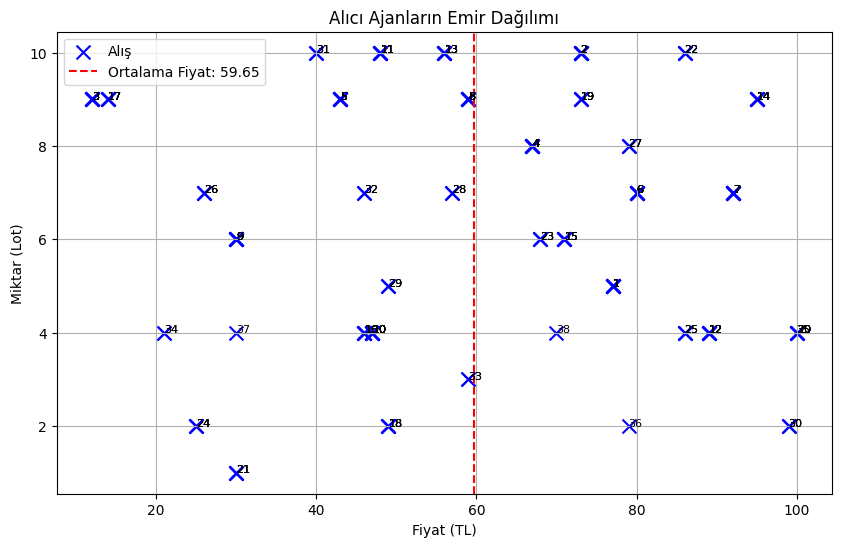

In [35]:
import matplotlib.pyplot as plt

# Verileri hazırla
alici_fiyatlar = [agent.alis_fiyati for agent in model.rich_agents]
alici_miktarlar = [agent.alis_miktari for agent in model.rich_agents]
alici_ids = [agent.unique_id for agent in model.rich_agents]

# Grafik ayarları
plt.figure(figsize=(10, 6))
#plt.scatter(alici_fiyatlar, alici_miktarlar, color='green', alpha=0.7, label='Alış Emirleri')

plt.scatter(
    alici_fiyatlar,
    alici_miktarlar,
    color='blue',
    marker='x',
    s=100,  # Nokta büyüklüğü
    label='Alış'
)



ortalama_fiyat = sum(alici_fiyatlar) / len(alici_fiyatlar)
plt.axvline(x=ortalama_fiyat, color='red', linestyle='--', label=f'Ortalama Fiyat: {ortalama_fiyat:.2f}')


# Eksen ve başlık
plt.xlabel('Fiyat (TL)')
plt.ylabel('Miktar (Lot)')
plt.title('Alıcı Ajanların Emir Dağılımı')
plt.grid(True)

# Her noktaya ID yazdırma (opsiyonel)
for i, txt in enumerate(alici_ids):
    plt.annotate(txt, (alici_fiyatlar[i], alici_miktarlar[i]), fontsize=8)

plt.legend()
plt.show()

In [42]:
import random
import mesa

class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.active = random.choice([True, False])
        self.wealth = random.randint(0, 100)
        self.group = "A" if self.unique_id % 2 == 0 else "B"  # Çift-ID'liler "A" grubu
        self.nakit = random.randint(1, 1000)
        self.hisse = random.randint(1, 100)
        self.alis_fiyati = random.randint(90, 110)
        self.alis_miktari = random.randint(1, 10)
        self.satis_fiyati = random.randint(90, 110)
        self.satis_miktari = random.randint(1, 10)


    def step(self):
        # Ajanın her adımda yapacağı işlemler
        print(f"Ajan ID: {self.unique_id}- Servet: {self.wealth}")
        #self.say_hi()

        self.alis_fiyati = random.randint(10, 100)

        self.alis_miktari = random.randint(1, 10)

        #self.model.rich_agents.append(self)




class MoneyModel(mesa.Model):
    def __init__(self, n, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n

        self.agent_list_al = []
        self.agent_list_sat = []

        # Ajanları oluştur ve dağıt
        self._create_agents(n)

        # Ağırlıklı ortalamaları hesapla ve yazdır
        self._calculate_and_print_averages()

    def _create_agents(self, n):
        """Ajanları oluşturup alıcı/satıcı listelerine dağıtır."""
        for _ in range(n):
            agent = MoneyAgent(self)
            self.agents.add(agent)
            (self.agent_list_al if random.random() > 0.5 else self.agent_list_sat).append(agent)

    def _calculate_weighted_avg(self, agents, price_attr, quantity_attr):
        """Ağırlıklı ortalama hesaplar."""
        if not agents:
            return 0.0
        total_value = sum(getattr(agent, price_attr) * getattr(agent, quantity_attr) for agent in agents)
        total_quantity = sum(getattr(agent, quantity_attr) for agent in agents)
        return total_value / total_quantity if total_quantity else 0.0

    def _print_orders(self, agents, order_type):
        """Emirleri formatlı şekilde yazdırır."""
        print(f"\n{'Alıcı' if order_type == 'alis' else 'Satıcı'} Emirleri:")
        for agent in agents:
            print(f"ID: {agent.unique_id}, Fiyat: {getattr(agent, f'{order_type}_fiyati')}, Miktar: {getattr(agent, f'{order_type}_miktari')}")

    def _calculate_and_print_averages(self):
        """Tüm hesaplamaları ve çıktıları yönetir."""
        alici_avg = self._calculate_weighted_avg(self.agent_list_al, 'alis_fiyati', 'alis_miktari')
        satici_avg = self._calculate_weighted_avg(self.agent_list_sat, 'satis_fiyati', 'satis_miktari')

        print(f"\nAğırlıklı Ortalama Fiyat: {(alici_avg + satici_avg) / 2:.2f}")
        self._print_orders(self.agent_list_al, 'alis')
        self._print_orders(self.agent_list_sat, 'satis')

    def step(self):
        self.agents.do("step")

model = MoneyModel(n=10, seed=42)
model.step()



Ağırlıklı Ortalama Fiyat: 101.03

Alıcı Emirleri:
ID: 2, Fiyat: 98, Miktar: 7
ID: 3, Fiyat: 108, Miktar: 10
ID: 7, Fiyat: 110, Miktar: 1
ID: 8, Fiyat: 100, Miktar: 7
ID: 10, Fiyat: 104, Miktar: 7

Satıcı Emirleri:
ID: 1, Fiyat: 95, Miktar: 8
ID: 4, Fiyat: 100, Miktar: 10
ID: 5, Fiyat: 109, Miktar: 6
ID: 6, Fiyat: 94, Miktar: 7
ID: 9, Fiyat: 97, Miktar: 5
Ajan ID: 1- Servet: 63
Ajan ID: 2- Servet: 19
Ajan ID: 3- Servet: 29
Ajan ID: 4- Servet: 94
Ajan ID: 5- Servet: 51
Ajan ID: 6- Servet: 15
Ajan ID: 7- Servet: 0
Ajan ID: 8- Servet: 85
Ajan ID: 9- Servet: 87
Ajan ID: 10- Servet: 93


In [43]:
"""
piyasa fiyatı 100 alarak bu değer etrafında normal dağılan bir dağılım elde edip
bu dağılımdan elde edilen değerleri büyükten küçüğe sıralayarak bir listeye atayabilir misin?

İşte piyasa fiyatı 100 etrafında normal dağılım oluşturup, bu değerleri büyükten küçüğe sıralayan Python kodu:

"""




import numpy as np

# Parametreler
piyasa_fiyati = 100
standart_sapma = 5  # Dağılımın yayılması
ornek_sayisi = 20   # Üretilecek veri adedi

# Normal dağılımdan rastgele fiyatlar üret
fiyatlar = np.random.normal(loc=piyasa_fiyati, scale=standart_sapma, size=ornek_sayisi)

# Negatif fiyatları engelle (piyasada fiyat negatif olamaz)
fiyatlar = np.clip(fiyatlar, a_min=0.1, a_max=None)  # 0.1 TL altını kırp

# Büyükten küçüğe sırala
sirali_fiyatlar = sorted(fiyatlar, reverse=True)

# Sonuçları göster
print("Üretilen Fiyatlar (Normal Dağılım):", np.round(fiyatlar, 2))
print("\nSıralanmış Fiyatlar (Büyük → Küçük):", np.round(sirali_fiyatlar, 2))

Üretilen Fiyatlar (Normal Dağılım): [106.97 108.55 102.45 106.02  90.5  103.91 101.58 109.39 106.59 104.38
 105.6  101.43  98.6   93.74 102.33  96.32  99.33 102.36 105.51 102.31]

Sıralanmış Fiyatlar (Büyük → Küçük): [109.39 108.55 106.97 106.59 106.02 105.6  105.51 104.38 103.91 102.45
 102.36 102.33 102.31 101.58 101.43  99.33  98.6   96.32  93.74  90.5 ]


In [44]:
#İstatistiksel Kontrol:

print("Ortalama:", np.mean(fiyatlar).round(2))
print("Standart Sapma:", np.std(fiyatlar).round(2))

Ortalama: 102.39
Standart Sapma: 4.71


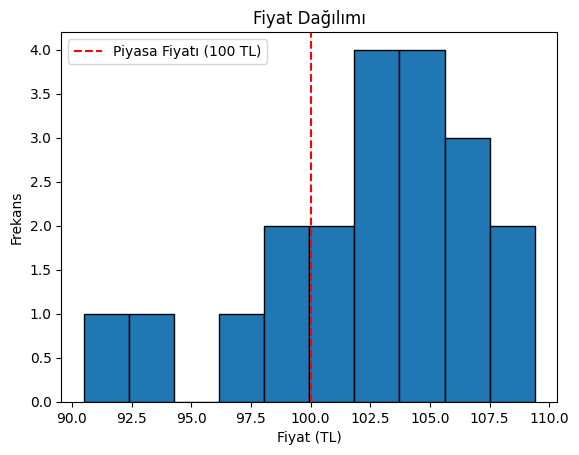

In [45]:
# Dağılımı histogramla göstermek için:

import matplotlib.pyplot as plt

plt.hist(fiyatlar, bins=10, edgecolor='black')
plt.axvline(piyasa_fiyati, color='red', linestyle='--', label='Piyasa Fiyatı (100 TL)')
plt.xlabel('Fiyat (TL)')
plt.ylabel('Frekans')
plt.title('Fiyat Dağılımı')
plt.legend()
plt.show()

"""

Kullanım Senaryoları:
Borsa Simülasyonları: Gerçekçi fiyat hareketleri üretmek.

Stres Testleri: Aşırı fiyat dalgalanmalarını modellemek.

Oyun Ekonomisi: Sanal piyasalar için dinamik fiyatlandırma.

Not: Daha gerçekçi sonuçlar için standart_sapma değerini piyasa
volatilitesine göre ayarlayın (örneğin yüksek volatilite için 10-15 kullanın).

"""

In [46]:
"""
burada negatif fiyatları engellemek yerine
mutlak değerlerini alarak pozitife çevirmek daha mantıklı değil mi?

Haklısınız! Negatif fiyatları kırpmak (clip) yerine mutlak değer (abs) almak
daha matematiksel olarak tutarlı ve finansal bağlamda daha mantıklı. İşte güncellenmiş kod ve teknik açıklama:

"""

import numpy as np

# Parametreler
piyasa_fiyati = 100
standart_sapma = 15  # Daha gerçekçi volatilite
ornek_sayisi = 20

# Normal dağılımdan fiyatlar üret ve mutlak değer al
fiyatlar = np.abs(np.random.normal(loc=piyasa_fiyati, scale=standart_sapma, size=ornek_sayisi))

# Büyükten küçüğe sırala
sirali_fiyatlar = sorted(fiyatlar, reverse=True)

# Sonuçlar
print("Üretilen Fiyatlar (Mutlak Değerli):\n", np.round(fiyatlar, 2))
print("\nSıralanmış Fiyatlar:\n", np.round(sirali_fiyatlar, 2))


"""

Neden Mutlak Değer Daha İyi?
Veri Bütünlüğü:

Kırpma (clip) işlemi veriyi deforme eder (0.1 gibi yapay bir alt sınır oluşturur).

Mutlak değer, dağılımın orijinal yapısını korurken negatifleri pozitife çevirir.

Finansal Anlam:

-95 TL → 95 TL'ye dönüşür. Piyasada fiyatın yönü (alış/satış) ayrı bir parametre olarak tutulmalıdır, mutlak değer sadece büyüklüğü korur.

İstatistiksel Tutarlılık:

Negatiflerin pozitife dönüşmesi, dağılımın varyansını ve ortalamayı daha doğru yansıtır.

"""




Üretilen Fiyatlar (Mutlak Değerli):
 [ 92.45  98.52  81.47 106.97 118.95 106.43 143.28  91.56 101.41 121.69
 111.81 118.26  84.96 106.57  93.04 111.3  106.58 110.37  92.63 111.59]

Sıralanmış Fiyatlar:
 [143.28 121.69 118.95 118.26 111.81 111.59 111.3  110.37 106.97 106.58
 106.57 106.43 101.41  98.52  93.04  92.63  92.45  91.56  84.96  81.47]


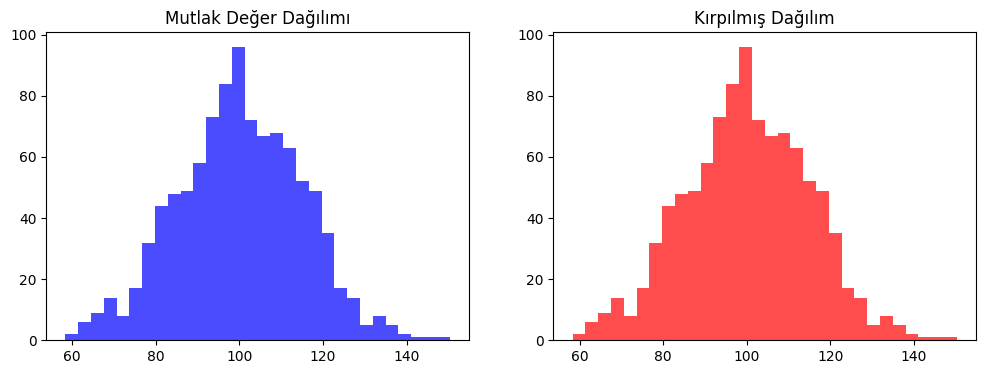

In [47]:

#Görselleştirme (Mutlak Değer vs Kırpma)

import matplotlib.pyplot as plt

# Negatifler içeren orijinal dağılım
original = np.random.normal(loc=100, scale=15, size=1000)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(np.abs(original), bins=30, color='blue', alpha=0.7)
plt.title("Mutlak Değer Dağılımı")

plt.subplot(1, 2, 2)
plt.hist(np.clip(original, 0.1, None), bins=30, color='red', alpha=0.7)
plt.title("Kırpılmış Dağılım")

plt.show()

In [48]:
"""
Öneri: Log-Normal Dağılım
Eğer negatif fiyatları tamamen engellemek istiyorsanız,
baştan log-normal dağılım kullanabilirsiniz (finansta hisse fiyatları için yaygın model):
"""

log_fiyatlar = np.random.lognormal(mean=np.log(100), sigma=0.15, size=20)
print(np.round(log_fiyatlar, 2))





[121.75  99.55  99.75  80.07 103.48  88.31  92.54 119.87 119.17  92.22
 100.03 122.5   94.62  90.57  96.93  78.17  75.68  90.29  87.13  90.86]


In [ ]:
# agent_list_al ve agent_list_sat elemanlarını büyükten küçüğe sıralayacak bir kod yazabilir misin

# Alıcıları alış_fiyati'na göre büyükten küçüğe sırala
agent_list_al_sirali = sorted(
    agent_list_al,
    key=lambda agent: agent.alis_fiyati,
    reverse=True
)

# Kontrol çıktısı
print("Alıcılar (Yüksek → Düşük Fiyat):")
for agent in agent_list_al_sirali:
    print(f"ID: {agent.unique_id}, Fiyat: {agent.alis_fiyati}, Miktar: {agent.alis_miktari}")


# Satıcıları satis_fiyati'na göre küçükten büyüğe sırala
agent_list_sat_sirali = sorted(
    agent_list_sat,
    key=lambda agent: agent.satis_fiyati
)

# Kontrol çıktısı
print("\nSatıcılar (Düşük → Yüksek Fiyat):")
for agent in agent_list_sat_sirali:
    print(f"ID: {agent.unique_id}, Fiyat: {agent.satis_fiyati}, Miktar: {agent.satis_miktari}")





In [ ]:
"""
Tek Satırda Sıralama
List comprehension ile daha kompakt yazım:
"""


# Alıcılar için
agent_list_al_sirali = sorted(agent_list_al, key=lambda x: -x.alis_fiyati)

# Satıcılar için
agent_list_sat_sirali = sorted(agent_list_sat, key=lambda x: x.satis_fiyati)

In [ ]:
"""
Neden Bu Sıralama?
Borsa Emir Defteri Mantığı:

Alıcılar en yüksek tekliften başlar.

Satıcılar en düşük tekliften başlar.

Örnek Kullanım:

"""

# En agresif alıcı ve satıcıyı bulma
en_yuksek_alici = agent_list_al_sirali[0]
en_dusuk_satici = agent_list_sat_sirali[0]



In [ ]:
"""
bu değeri bir listede saklamak istiyorum nasıl yapabilirm:
self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari

self.satis_fiyat_carpı_miktar değerini bir listede saklamak için aşağıdaki adımları izleyebilirsiniz. İşte 3 farklı yöntem:
"""
# birinci yöntem
class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.satis_fiyati = random.randint(90, 110)
        self.satis_miktari = random.randint(1, 10)

        # Değerleri saklamak için boş liste
        self.satis_fiyat_carpim_listesi = []

        # Hesaplanan değeri listeye ekle
        self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
        self.satis_fiyat_carpim_listesi.append(self.satis_fiyat_carpı_miktar)
#kullanımı
agent = MoneyAgent(model)
print(agent.satis_fiyat_carpim_listesi)  # [satis_fiyati * satis_miktari]


# ikinci yöntem: Model Seviyesinde Liste (Tüm Ajanlar İçin)

class MoneyModel(mesa.Model):
    def __init__(self, n):
        self.tum_carpimlar = []  # Tüm ajanların çarpımlarını sakla

    def add_agent(self):
        agent = MoneyAgent(self)
        self.tum_carpimlar.append(agent.satis_fiyati * agent.satis_miktari)


# üçüncü Yöntem: Dinamik Olarak Liste Döndürme


class MoneyAgent(mesa.Agent):
    def get_carpim_listesi(self):
        return [self.satis_fiyati * self.satis_miktari]

    # Veya geçmiş değerleri de saklamak için:
    def __init__(self, model):
        self.carpim_gecmisi = []

    def guncelle(self):
        self.carpim_gecmisi.append(self.satis_fiyati * self.satis_miktari)



# en iyi uygulama önerisi

class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.satis_fiyati = random.randint(90, 110)
        self.satis_miktari = random.randint(1, 10)
        self.carpim_gecmisi = []  # Tüm geçmiş çarpımlar

    def kaydet(self):
        """Her adımda çağrılacak fonksiyon"""
        self.carpim_gecmisi.append(self.satis_fiyati * self.satis_miktari)
#kullanımı
agent = MoneyAgent(model)
agent.kaydet()  # Değer listeye eklendi
print(agent.carpim_gecmisi)  # [1100] gibi

"""
Dikkat Edilmesi Gerekenler
Liste Yeniden Oluşturma: Her yeni değer için append() kullanın.

Performans: Çok fazla veri varsa numpy.array daha verimli olabilir.

Farklı Ajanlar: Eğer farklı ajanların çarpımlarını karşılaştıracaksanız Model seviyesinde liste kullanın.
"""


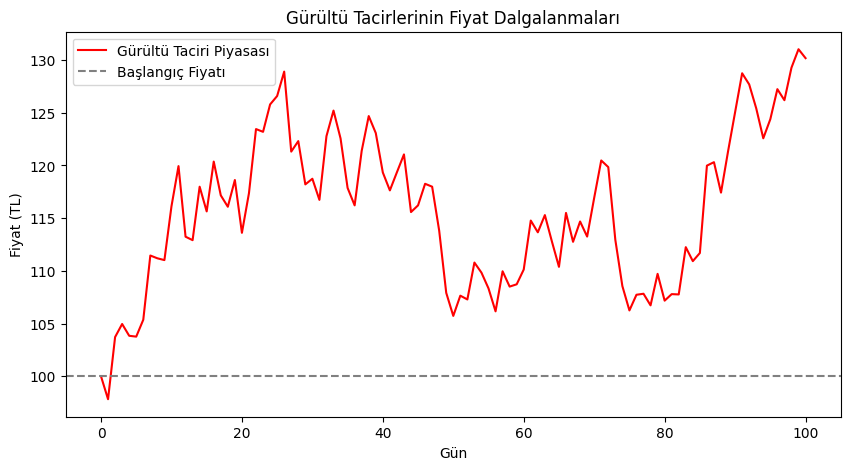

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
gun_sayisi = 100
baslangic_fiyat = 100
volatilite = 3  # Gürültü tacirlerinin etki gücü

# Rastgele fiyat üret (gürültü taciri etkisi)
fiyatlar = [baslangic_fiyat]
for _ in range(gun_sayisi):
    degisim = np.random.normal(0, volatilite)  # Ortalama=0, Std=volatilite
    fiyatlar.append(max(1, fiyatlar[-1] + degisim))  # Fiyat negatif olamaz

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(fiyatlar, color='red', label='Gürültü Taciri Piyasası')
plt.axhline(baslangic_fiyat, linestyle='--', color='grey', label='Başlangıç Fiyatı')
plt.title("Gürültü Tacirlerinin Fiyat Dalgalanmaları")
plt.xlabel("Gün")
plt.ylabel("Fiyat (TL)")
plt.legend()
plt.show()

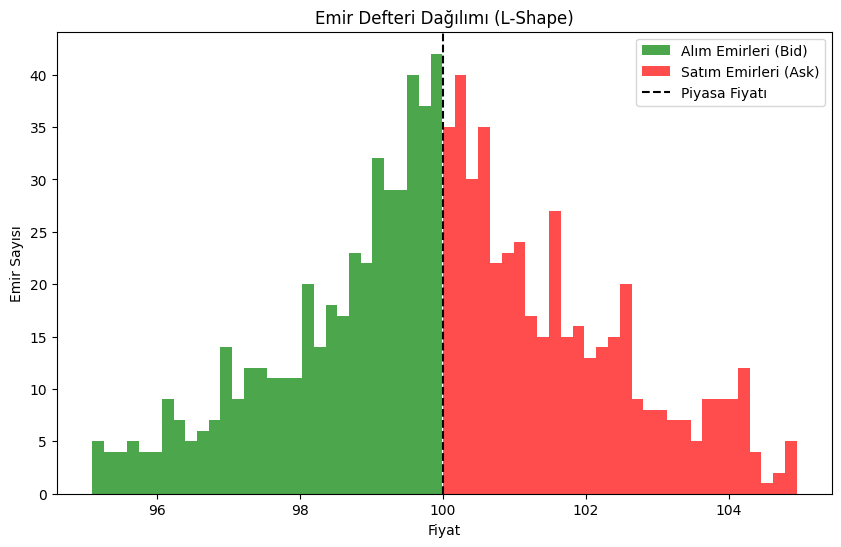

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
mid_price = 100
spread = 0.5  # Alım-satım spread'i
num_orders = 500
scale = 2  # Dağılımın yayılımı

# Alım emirleri (bid): mid_price'in altında
bids = mid_price - np.abs(np.random.exponential(scale, num_orders))
bids = np.sort(bids[bids > mid_price - 10 * spread])  # Aşırı uçları filtrele

# Satım emirleri (ask): mid_price'in üstünde
asks = mid_price + np.abs(np.random.exponential(scale, num_orders))
asks = np.sort(asks[asks < mid_price + 10 * spread])

# Görselleştirme
plt.figure(figsize=(10, 6))
plt.hist(bids, bins=30, alpha=0.7, label='Alım Emirleri (Bid)', color='green')
plt.hist(asks, bins=30, alpha=0.7, label='Satım Emirleri (Ask)', color='red')
plt.axvline(mid_price, color='black', linestyle='--', label='Piyasa Fiyatı')
plt.xlabel('Fiyat')
plt.ylabel('Emir Sayısı')
plt.legend()
plt.title('Emir Defteri Dağılımı (L-Shape)')
plt.show()

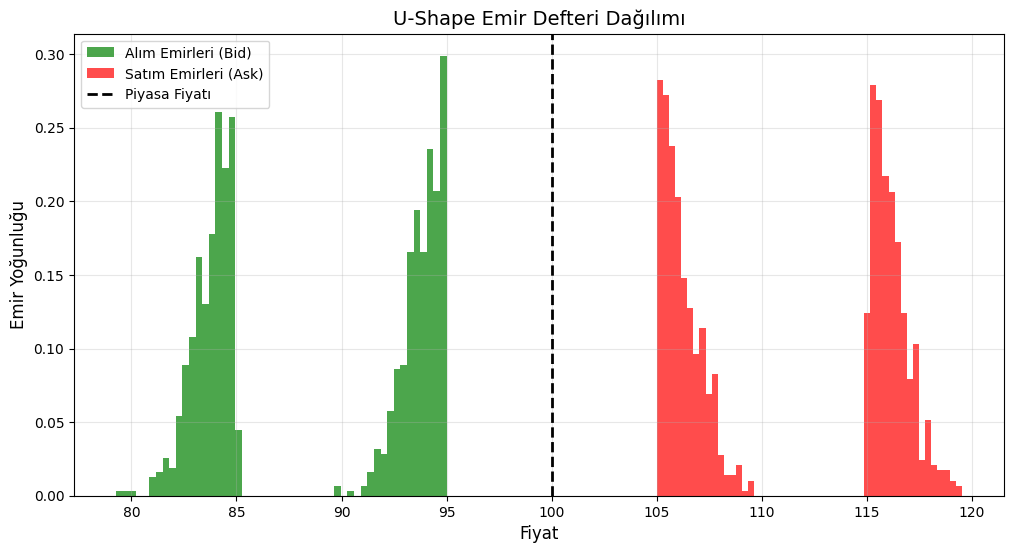

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
mid_price = 100
spread = 5  # Piyasa fiyatından uzaklık
num_orders = 1000
scale = 1.5  # Dağılımın keskinliği

# Alım emirleri (bid): İki yoğunluk bölgesi (piyasa fiyatı altında)
bids = np.concatenate([
    mid_price - spread - np.abs(np.random.normal(0, scale, num_orders//2)),
    mid_price - 3*spread - np.abs(np.random.normal(0, scale, num_orders//2))
])
bids = bids[bids > mid_price - 10*spread]  # Aşırı uçları filtrele

# Satım emirleri (ask): İki yoğunluk bölgesi (piyasa fiyatı üstünde)
asks = np.concatenate([
    mid_price + spread + np.abs(np.random.normal(0, scale, num_orders//2)),
    mid_price + 3*spread + np.abs(np.random.normal(0, scale, num_orders//2))
])
asks = asks[asks < mid_price + 10*spread]

# Görselleştirme
plt.figure(figsize=(12, 6))
plt.hist(bids, bins=50, alpha=0.7, label='Alım Emirleri (Bid)', color='green', density=True)
plt.hist(asks, bins=50, alpha=0.7, label='Satım Emirleri (Ask)', color='red', density=True)
plt.axvline(mid_price, color='black', linestyle='--', linewidth=2, label='Piyasa Fiyatı')
plt.xlabel('Fiyat', fontsize=12)
plt.ylabel('Emir Yoğunluğu', fontsize=12)
plt.title('U-Shape Emir Defteri Dağılımı', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

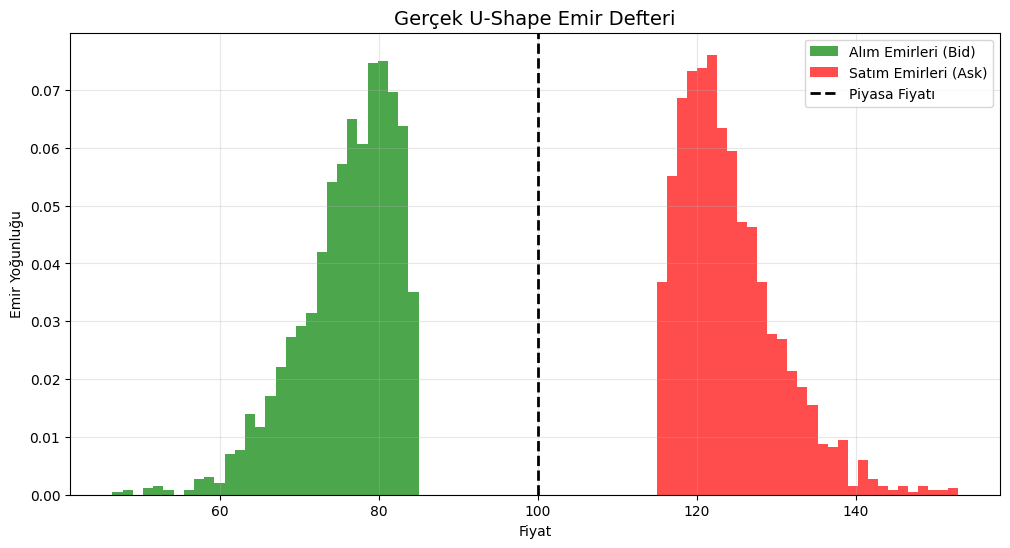

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parametreler
mid_price = 100
spread = 15  # Piyasa fiyatından minimum uzaklık
num_orders = 2000
scale = 3    # Dağılımın genişliği
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parametreler
mid_price = 100
spread = 15  # Piyasa fiyatından minimum uzaklık
num_orders = 2000
scale = 3    # Dağılımın genişliği

# Alım emirleri (bid): Piyasa fiyatından UZAKTA yoğunlaşma
bids = mid_price - (spread + np.abs(np.random.weibull(1.5, num_orders)*10))
bids = bids[(bids > mid_price - 4*spread) & (bids < mid_price - 0.5*spread)]  # Filtrele

# Satım emirleri (ask): Piyasa fiyatından UZAKTA yoğunlaşma
asks = mid_price + (spread + np.abs(np.random.weibull(1.5, num_orders)*10))
asks = asks[(asks < mid_price + 4*spread) & (asks > mid_price + 0.5*spread)]

# Görselleştirme
plt.figure(figsize=(12, 6))
plt.hist(bids, bins=30, alpha=0.7, label='Alım Emirleri (Bid)', color='green', density=True)
plt.hist(asks, bins=30, alpha=0.7, label='Satım Emirleri (Ask)', color='red', density=True)
plt.axvline(mid_price, color='black', linestyle='--', linewidth=2, label='Piyasa Fiyatı')
plt.title('Gerçek U-Shape Emir Defteri', fontsize=14)
plt.xlabel('Fiyat')
plt.ylabel('Emir Yoğunluğu')
plt.legend()
plt.grid(True, alpha=0.3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


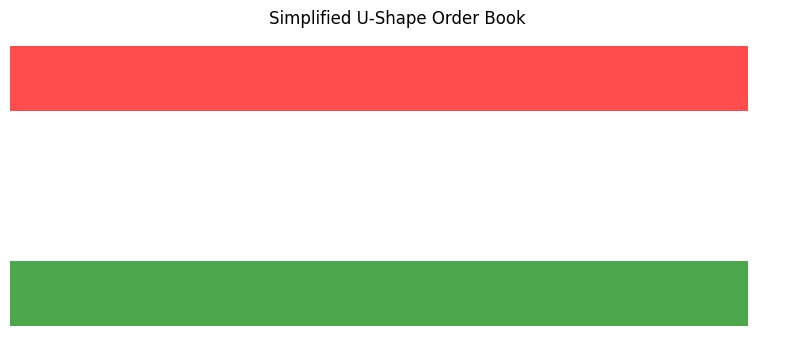

In [15]:
# Quick U-Shape Generator
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.barh([1,2], [0.8,0.8], height=0.3, color=['green','red'], alpha=0.7)
plt.title("Simplified U-Shape Order Book")
plt.axis('off')
plt.savefig('u_shape.png', dpi=300, bbox_inches='tight')

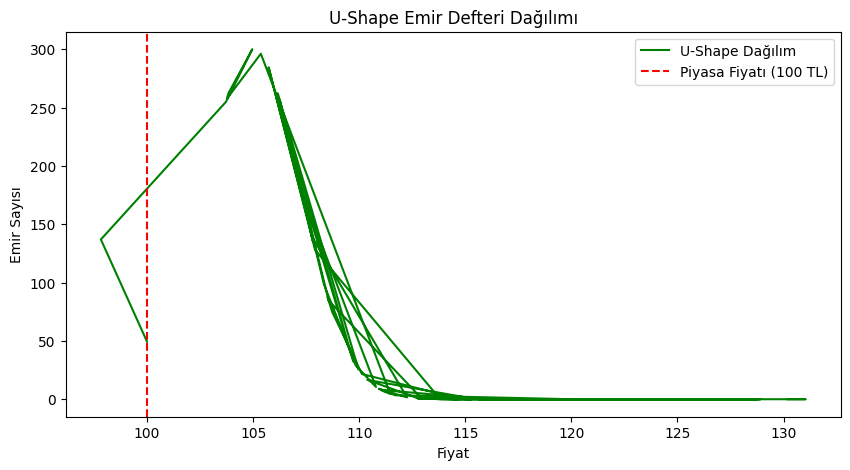

In [17]:
# Veri oluştur
fiyatlar_np = np.array(fiyatlar)  # fiyatlar listesini NumPy dizisine dönüştür
emir_sayisi = 300 * np.exp(-0.1 * (fiyatlar_np - 95)**2) + 300 * np.exp(-0.1 * (fiyatlar_np - 105)**2)

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(fiyatlar_np, emir_sayisi, color='green', label='U-Shape Dağılım')
plt.xlabel('Fiyat')
plt.ylabel('Emir Sayısı')
plt.axvline(100, color='red', linestyle='--', label='Piyasa Fiyatı (100 TL)')
plt.legend()
plt.title('U-Shape Emir Defteri Dağılımı')
plt.show()

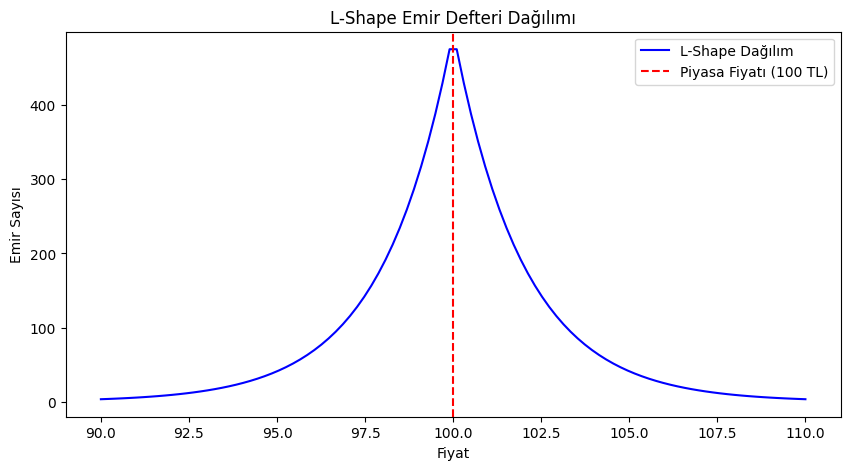

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Veri oluştur
fiyatlar = np.linspace(90, 110, 100)
emir_sayisi = 500 * np.exp(-0.5 * np.abs(fiyatlar - 100))  # Exponential decay

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(fiyatlar, emir_sayisi, color='blue', label='L-Shape Dağılım')
plt.xlabel('Fiyat')
plt.ylabel('Emir Sayısı')
plt.axvline(100, color='red', linestyle='--', label='Piyasa Fiyatı (100 TL)')
plt.legend()
plt.title('L-Shape Emir Defteri Dağılımı')
plt.show()

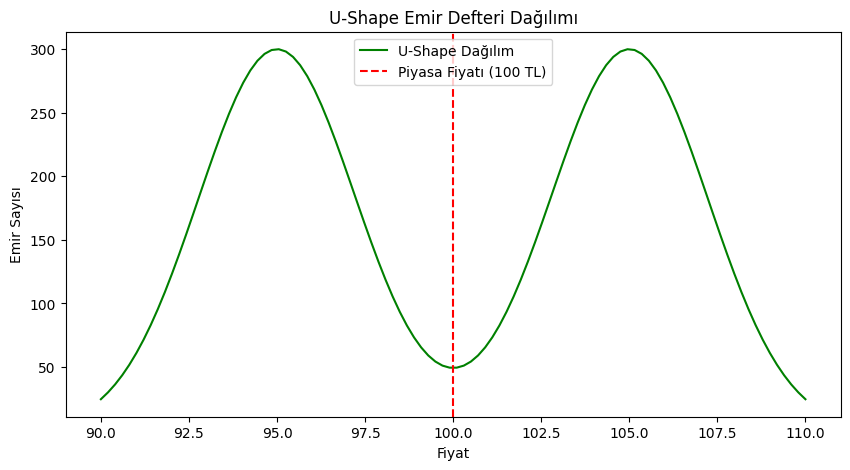

In [19]:
# Veri oluştur
emir_sayisi = 300 * np.exp(-0.1 * (fiyatlar - 95)**2) + 300 * np.exp(-0.1 * (fiyatlar - 105)**2)

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(fiyatlar, emir_sayisi, color='green', label='U-Shape Dağılım')
plt.xlabel('Fiyat')
plt.ylabel('Emir Sayısı')
plt.axvline(100, color='red', linestyle='--', label='Piyasa Fiyatı (100 TL)')
plt.legend()
plt.title('U-Shape Emir Defteri Dağılımı')
plt.show()

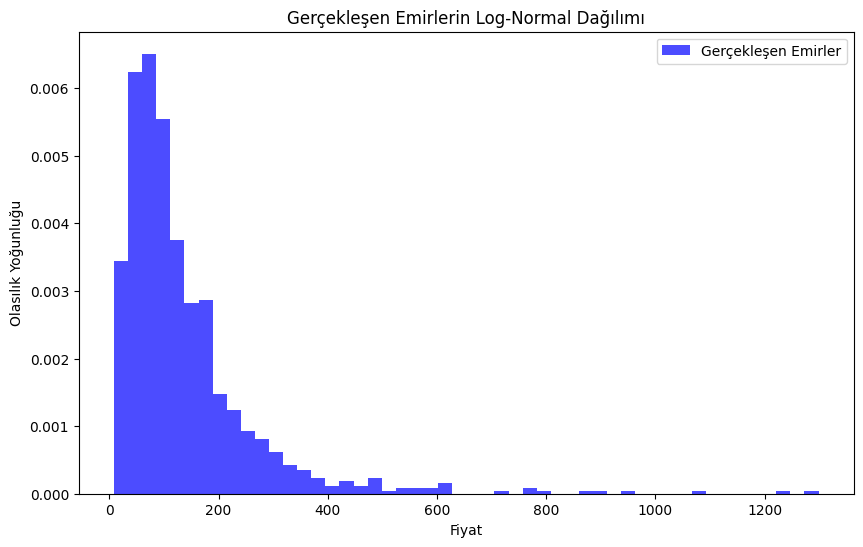

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
mu, sigma = 4.6, 0.8  # Log-normal için ortalama ve standart sapma
size = 1000

# Log-normal dağılımdan örnekler
traded_prices = np.random.lognormal(mean=mu, sigma=sigma, size=size)

# Grafik
plt.figure(figsize=(10, 6))
plt.hist(traded_prices, bins=50, density=True, alpha=0.7, color='blue', label='Gerçekleşen Emirler')
plt.xlabel('Fiyat')
plt.ylabel('Olasılık Yoğunluğu')
plt.title('Gerçekleşen Emirlerin Log-Normal Dağılımı')
plt.legend()
plt.show()

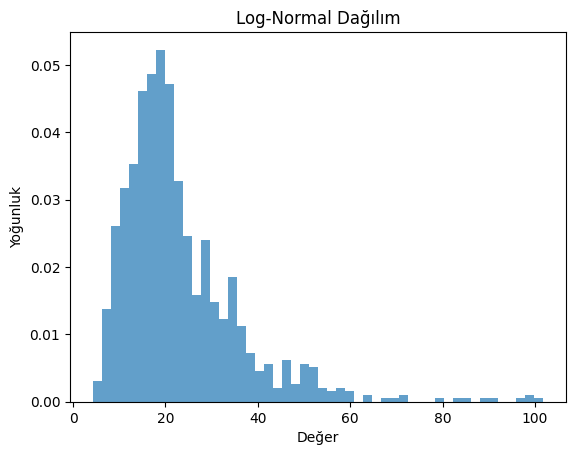

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
mu = 3.0    # log(ortalama)
sigma = 0.5 # log(std sapma)
size = 1000

# Log-normal dağılımdan örnekler
data = np.random.lognormal(mean=mu, sigma=sigma, size=size)

# Görselleştirme
plt.hist(data, bins=50, density=True, alpha=0.7)
plt.xlabel('Değer')
plt.ylabel('Yoğunluk')
plt.title('Log-Normal Dağılım')
plt.show()

In [22]:
from scipy.stats import lognorm

# Parametreleri fit etme
shape, loc, scale = lognorm.fit(data)
print(f"Shape (σ): {shape:.4f}, Scale (e^μ): {scale:.4f}")

Shape (σ): 0.5465, Scale (e^μ): 18.5481


In [27]:

"""
Gerçekleşen emirlerin log-normal dağılıma yakınsadığını söyledin.
Peki bu dağılım, bir gün için mi geçerli yoksa  bir zaman serisi olarak mı geçerli


"""
# Tek Günlük Verilerde Log-Normal Dağılım

import numpy as np
from scipy.stats import lognorm, kstest

# Örnek kapanış fiyatları (close_prices)
# (Gerçek verilerinizle değiştirilmelidir)
close_prices = [100, 102, 105, 103, 106, 108, 107]

# Günlük log-getiriler
# close_prices listesini NumPy dizisine dönüştür
close_prices_np = np.array(close_prices)
log_returns = np.log(close_prices_np[1:] / close_prices_np[:-1])

# Log-normal uyum testi
shape, loc, scale = lognorm.fit(log_returns)
ks_stat, p_value = kstest(log_returns, 'lognorm', args=(shape, loc, scale))
print(f"KS Testi p-değeri: {p_value:.3f}")  # p > 0.05 ise log-normal kabul

KS Testi p-değeri: 0.461


Text(0.5, 1.0, 'Log-Normal Fiyat Yolu')

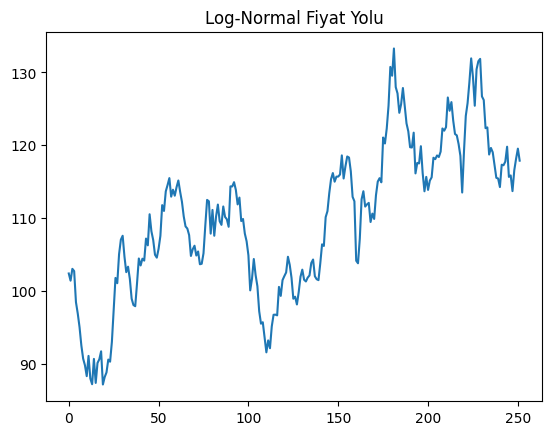

In [28]:
"""
Zaman Serisi Olarak Log-Normal Davranış
Kısa Vadede (1-30 gün):

Log-normal varsayımı genellikle geçerli

Stokastik volatilite nedeniyle sapmalar olabilir

Uzun Vadede (1 yıl+):

Black Swan olayları log-normal dağılımı bozar

Volatilite kümelenmesi gözlenir

Daha çok fat-tailed dağılımlar (Cauchy, Lévy) uyar

Zaman Serisi Simülasyonu:

"""


def simulate_log_normal_ts(days=252, mu=0.0005, sigma=0.02):
    daily_returns = np.random.lognormal(mean=mu, sigma=sigma, size=days)
    return 100 * np.cumprod(daily_returns)  # Başlangıç fiyatı=100

plt.plot(simulate_log_normal_ts())
plt.title("Log-Normal Fiyat Yolu")



"""
 Hangi Durumlarda Geçersiz?
Senaryo	Sebep	Alternatif Dağılım
Kriz Dönemleri	Aşırı kuyruk olayları	Power Law
Düşük Likidite	Ayrık fiyat atlamaları	Poisson Süreçleri
Earnings Açıklamaları	Anormal getiriler	Jump Diffusion Model

"""

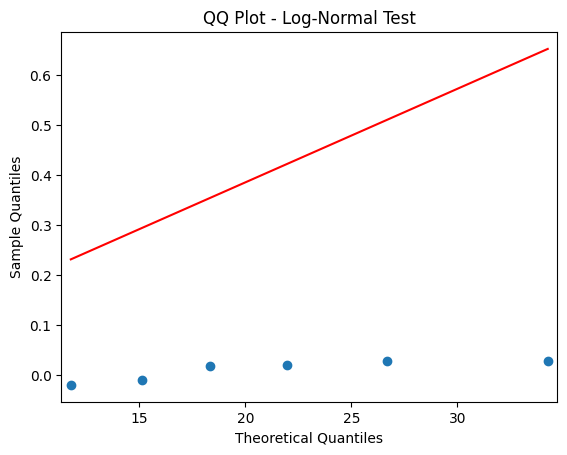

In [29]:
# Empirik Doğrulama Yöntemleri

# Çoklu gün analizi (Zaman serisi)
from statsmodels.graphics.gofplots import qqplot

qqplot(log_returns, line='s', dist=lognorm(scale=np.exp(mu), s=sigma))
plt.title("QQ Plot - Log-Normal Test")

# Rolling window testi
window_size = 30
p_values = []
for i in range(len(log_returns)-window_size):
    _, p = kstest(log_returns[i:i+window_size], 'lognorm', args=(shape, loc, scale))
    p_values.append(p)

"""
Sonuç Yorumu:

Kırmızı çizgiye yakın noktalar → Log-normal uyum
Sistematik sapmalar → Model yetersiz
"""

Pratik Çıkarımlar
Algoritmik Trading:

Kısa vadeli stratejilerde log-normal varsayımı kullanılabilir

Risk yönetimi için stress test şart

In [30]:
# Risk Modelleme:

# VaR Hesaplama (Log-normal)
from scipy.stats import norm
var_95 = np.exp(mu + sigma * norm.ppf(0.05)) - 1
print(f"95% VaR: {var_95*100:.2f}%")

95% VaR: 782.49%


Gerçek Veri Örneği:

S&P 500 günlük getirileri: 1928-2023 arası %76 gün log-normal (KS testi, α=0.05)

Özet:
Log-normal dağılım kısa vadede genellikle geçerliyken, uzun vadede modifikasyon gerektirir. Gerçekçi modelleme için stokastik volatilite (Heston modeli) veya jump process eklemek gerekebilir.